In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load datasets
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

Columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

Shape:
(90, 5)

First 5 Rows:
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

Data Types:
date               object
fund_house         object
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object

Column Names After Cleaning:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


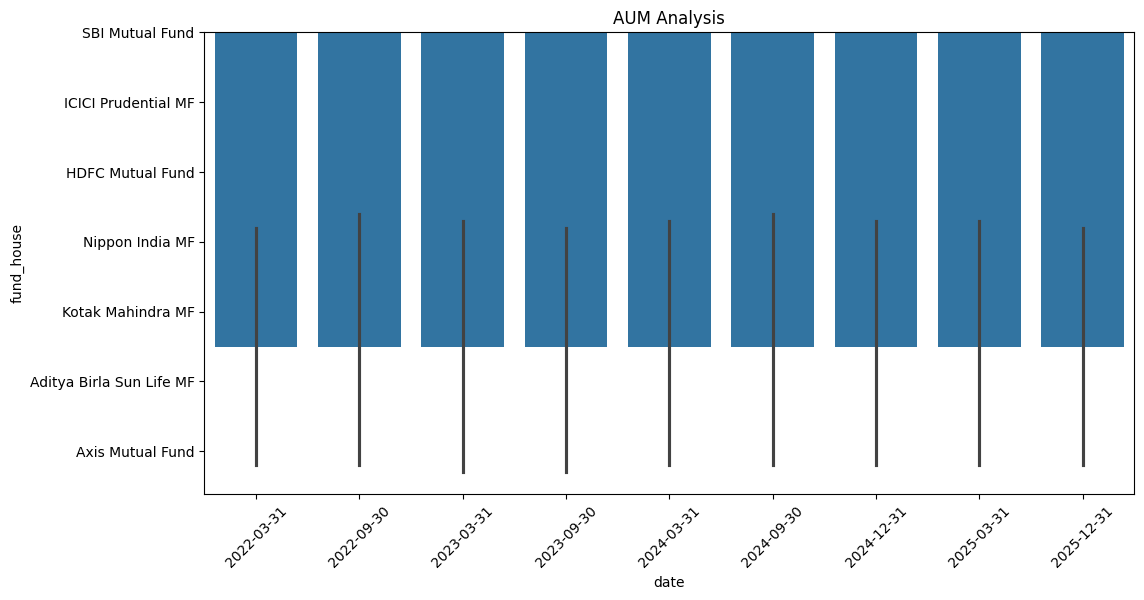

In [23]:
import pandas as pd

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print("Columns:")
print(aum.columns.tolist())

print("\nShape:")
print(aum.shape)

print("\nFirst 5 Rows:")
print(aum.head())

print("\nData Types:")
print(aum.dtypes)

aum.columns = aum.columns.str.strip()

print("\nColumn Names After Cleaning:")
print(aum.columns.tolist())
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.columns.tolist())

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x=aum.columns[0],
    y=aum.columns[1]
)

plt.title("AUM Analysis")
plt.xticks(rotation=45)
plt.show()

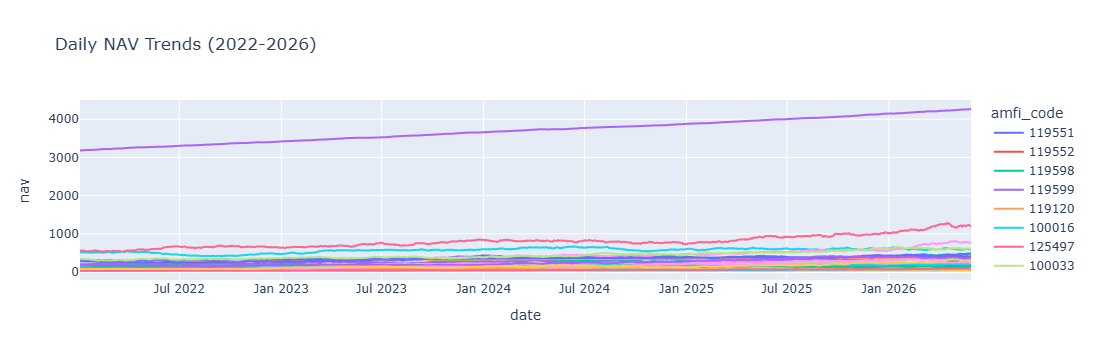

In [14]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends (2022-2026)"
)

fig.show()

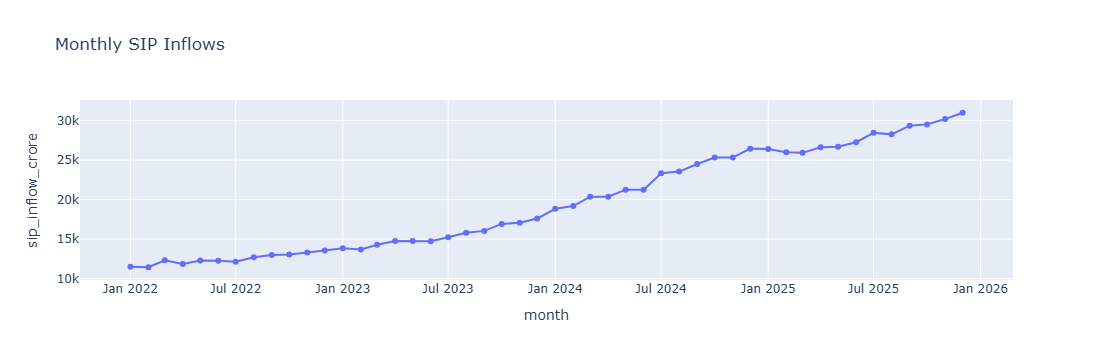

In [15]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows"
)

fig.show()

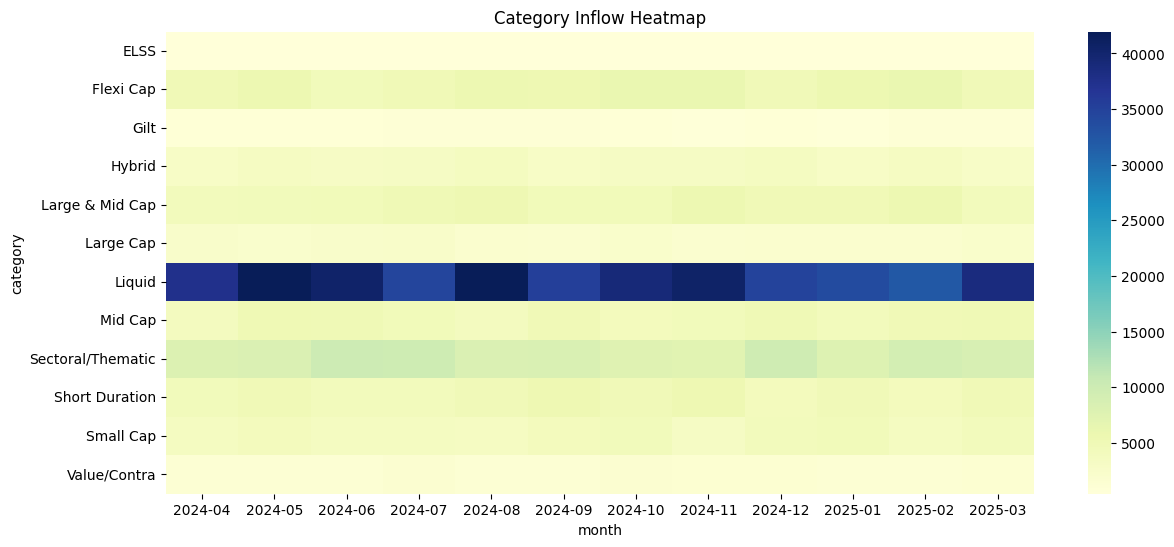

In [6]:
pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.show()

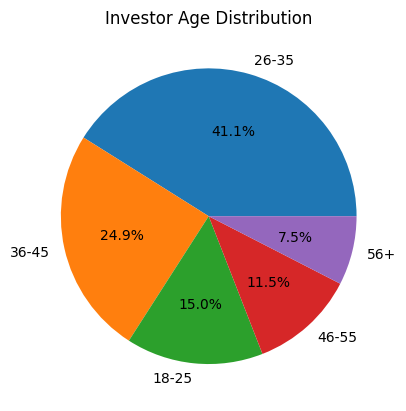

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [18]:
import matplotlib.pyplot as plt

investor["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")
plt.ylabel("")
plt.show()
print(investor.columns.tolist())

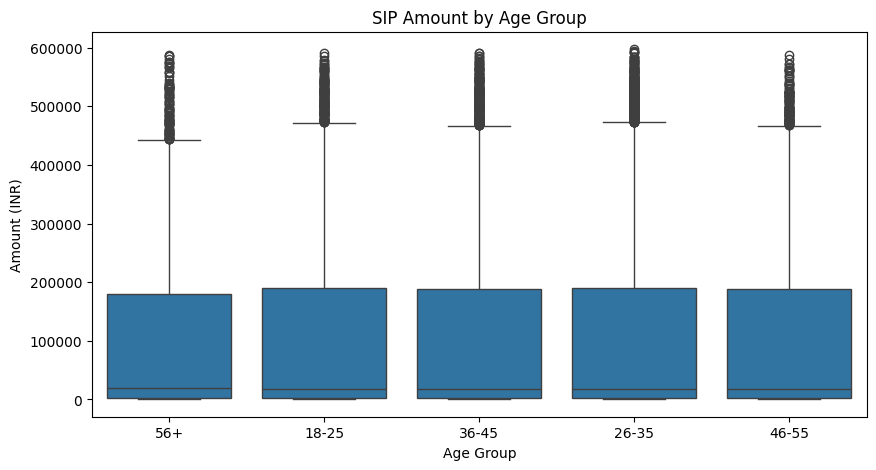

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.show()

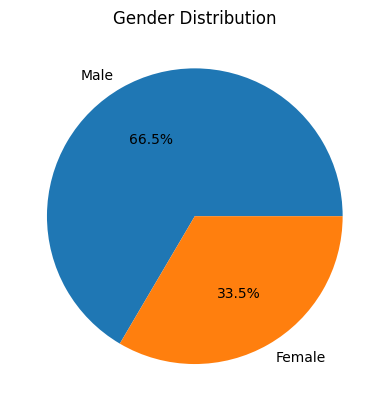

In [22]:
import matplotlib.pyplot as plt

investor["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()


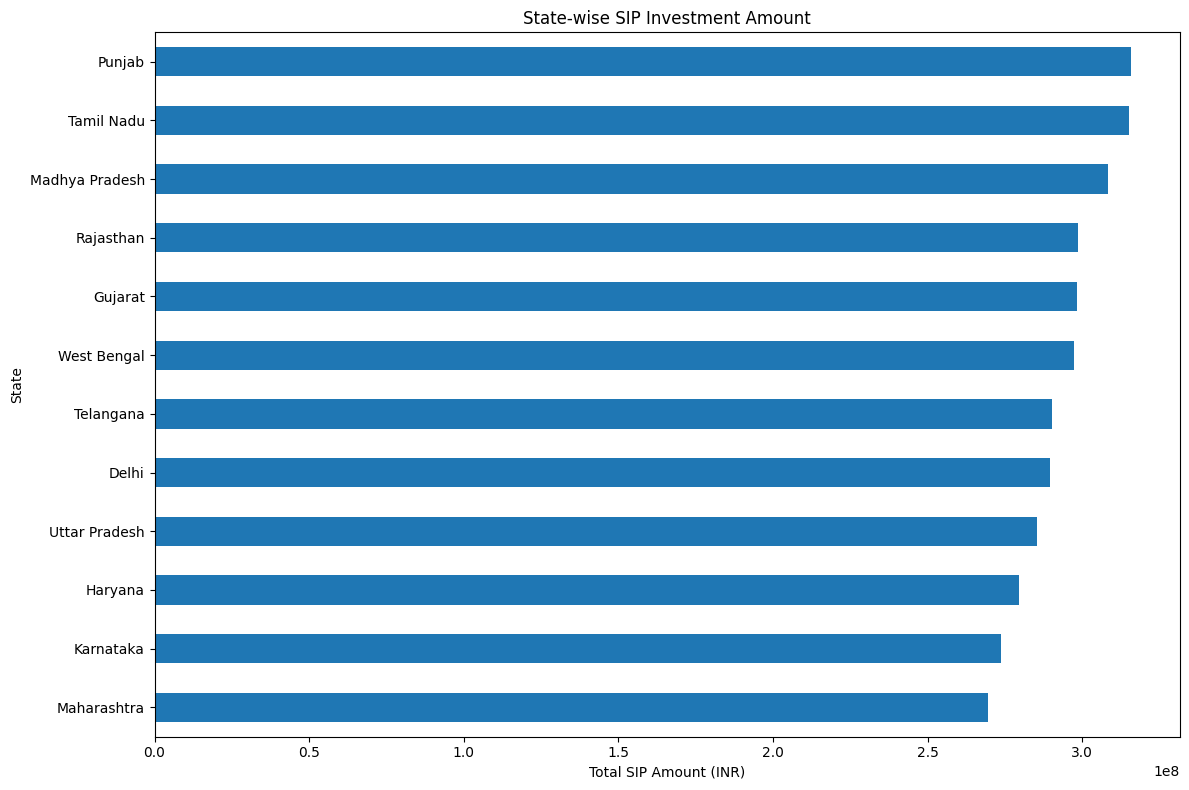

In [23]:
import matplotlib.pyplot as plt

# Total SIP amount by state
state_amount = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

state_amount.plot(
    kind="barh"
)

plt.title("State-wise SIP Investment Amount")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

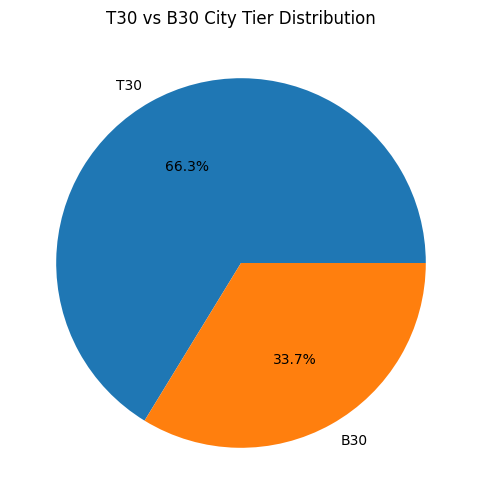

In [24]:
import matplotlib.pyplot as plt

investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("T30 vs B30 City Tier Distribution")
plt.ylabel("")
plt.show()

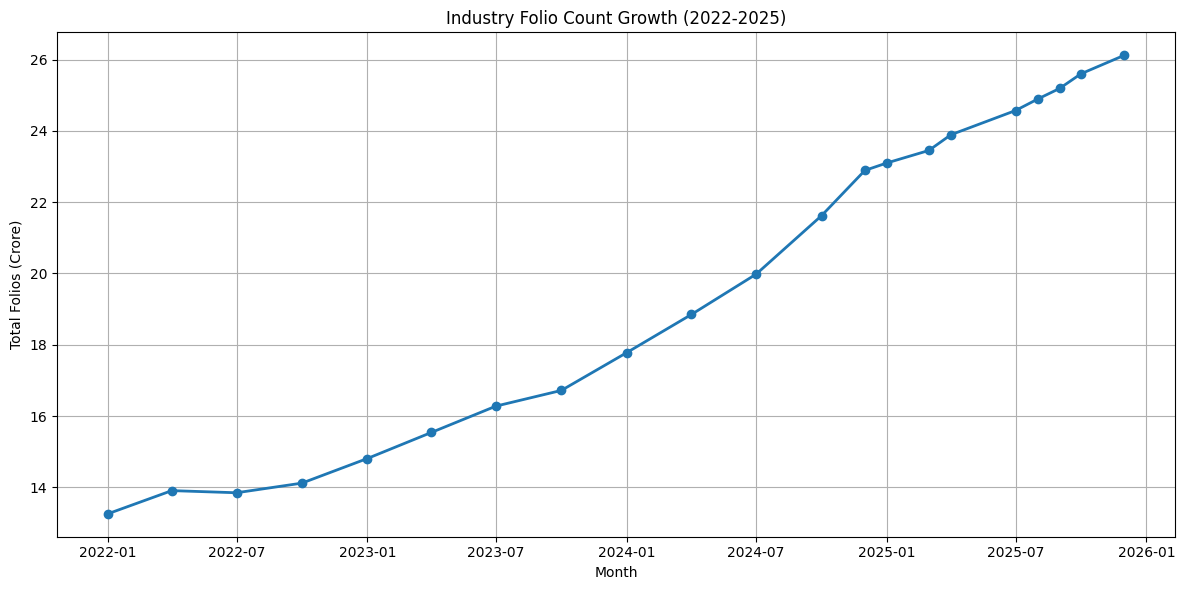

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert month column
folio["month"] = pd.to_datetime(folio["month"])

# Plot total folio growth
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.tight_layout()
plt.show()

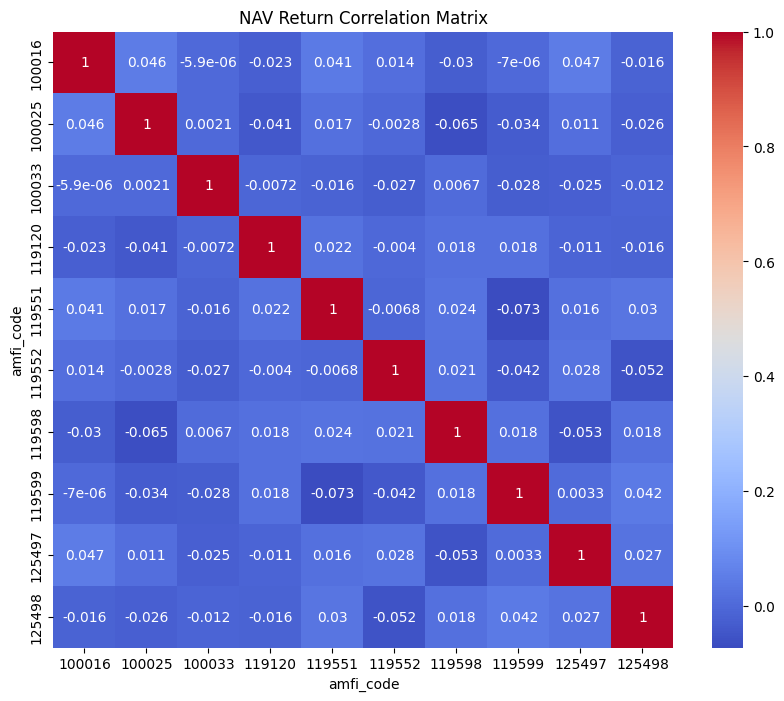

In [36]:
import seaborn as sns

nav["date"] = pd.to_datetime(nav["date"])

sample_funds = nav["amfi_code"].unique()[:10]

sample = nav[
    nav["amfi_code"].isin(sample_funds)
]

pivot_df = sample.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_df.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")
plt.show()

In [38]:
import pandas as pd

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Loaded Successfully!")

Loaded Successfully!


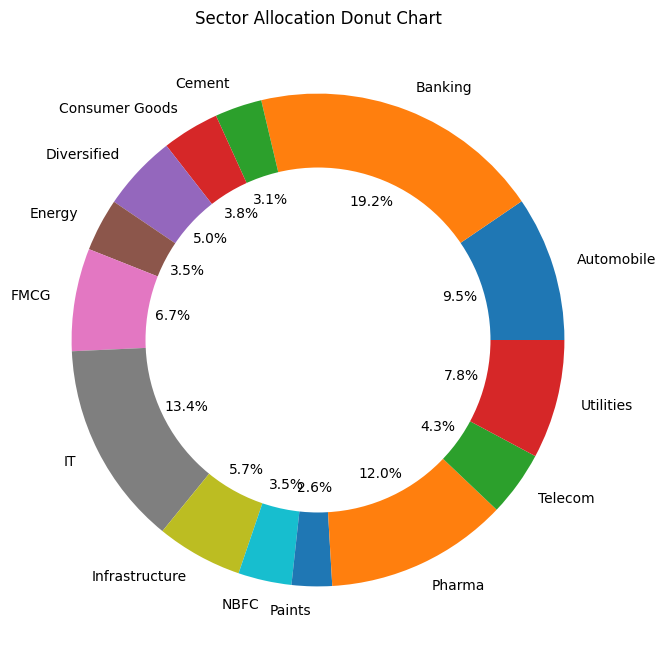

In [39]:
sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data["weight_pct"],
    labels=sector_data["sector"],
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Donut Chart")
plt.show()

In [6]:
import pandas as pd

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("Benchmark dataset loaded successfully")
print(benchmark.columns.tolist())

Benchmark dataset loaded successfully
['date', 'index_name', 'close_value']


In [12]:
import pandas as pd

funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [19]:
print(benchmark.columns.tolist())
benchmark.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


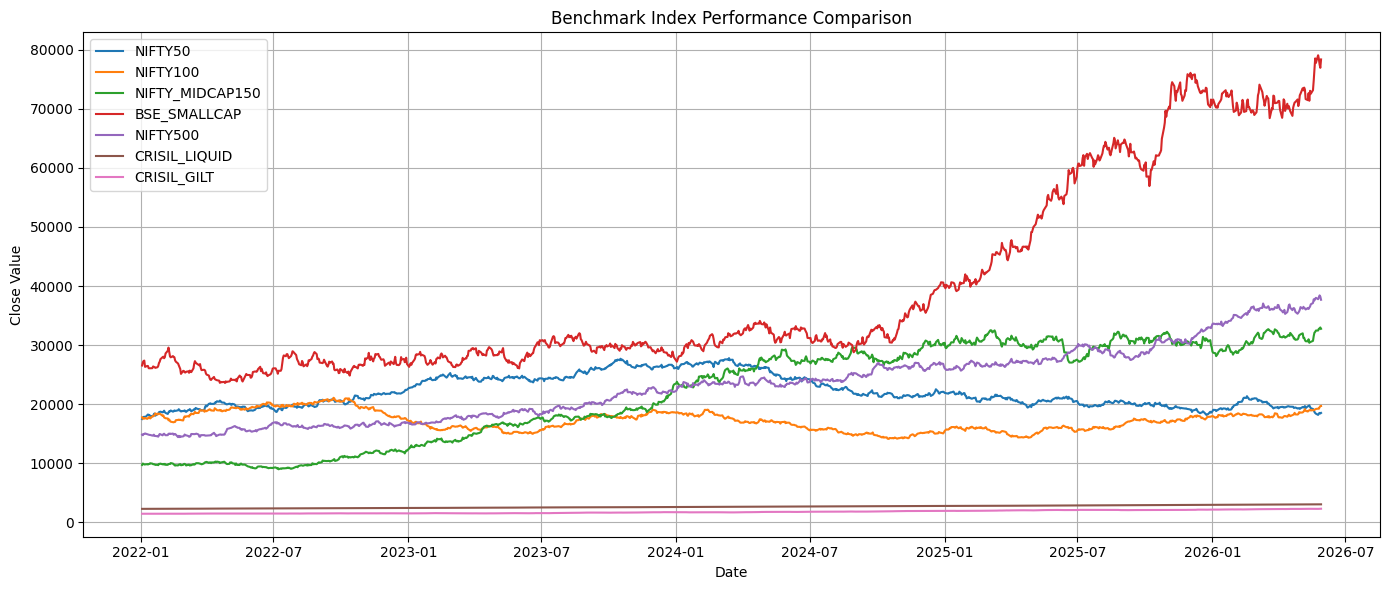

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert date column
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Create chart
plt.figure(figsize=(14,6))

for idx in benchmark["index_name"].unique():
    
    temp = benchmark[
        benchmark["index_name"] == idx
    ]
    
    plt.plot(
        temp["date"],
        temp["close_value"],
        label=idx
    )

plt.title("Benchmark Index Performance Comparison")
plt.xlabel("Date")
plt.ylabel("Close Value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

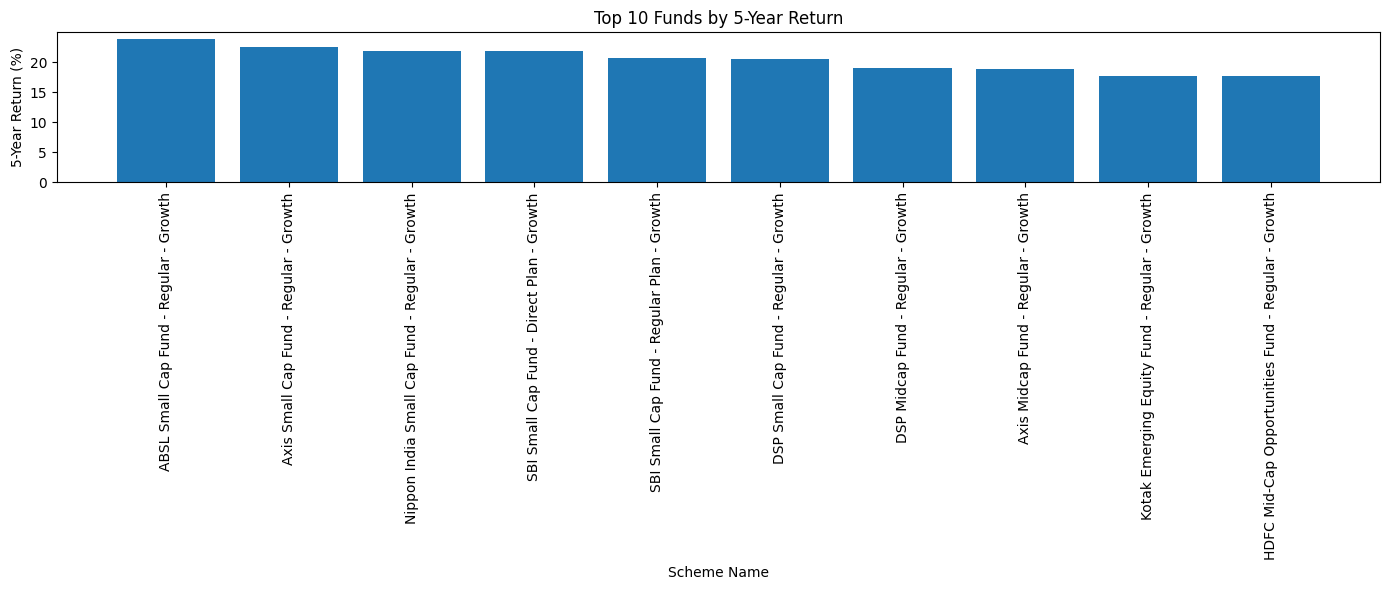

In [17]:
import matplotlib.pyplot as plt

# Top 10 funds by 5-year return
top10 = performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(14,6))

plt.bar(
    top10["scheme_name"],
    top10["return_5yr_pct"]
)

plt.title("Top 10 Funds by 5-Year Return")
plt.xlabel("Scheme Name")
plt.ylabel("5-Year Return (%)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

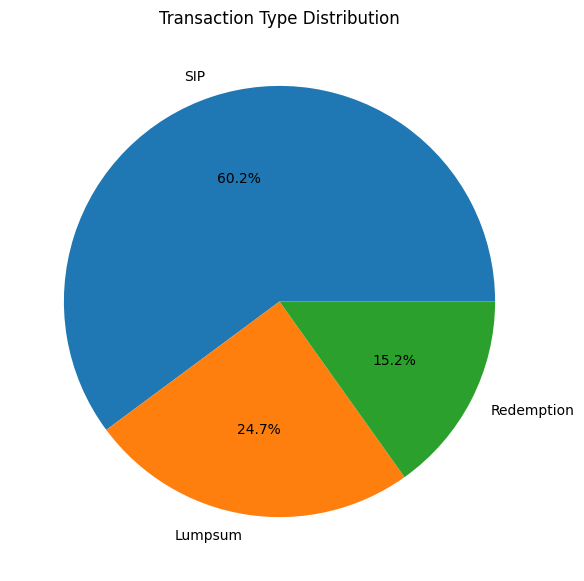

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

investor["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")
plt.ylabel("")

plt.show()